In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [22]:
#creating a DataFrame from the provided data
data = {
    'country': ['USA', 'Canada', 'France','UK','Germany','Australia'],
    'Latitude':[44.97,62.40,46.75,54.01,51.15,-25.45],
    'Longitude':[-103.77,-96.80,2.40,-2.53,10.40,133.11],
    'Language':['English','English','French','English','German','English']
}
df = pd.DataFrame(data)

    

In [23]:
df.head()

,country,Latitude,Longitude,Language
0,USA,44.97,-103.77,English
1,Canada,62.40,-96.80,English
2,France,46.75,2.40,French
3,UK,54.01,-2.53,English
4,Germany,51.15,10.40,German


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    6 non-null      object 
 1   Latitude   6 non-null      float64
 2   Longitude  6 non-null      float64
 3   Language   6 non-null      object 
dtypes: float64(2), object(2)
memory usage: 324.0+ bytes


In [25]:
#select the feature fir clustring (latitude and longitude)
X = df[['Latitude','Longitude']]

Text(0, 0.5, 'WCSS')

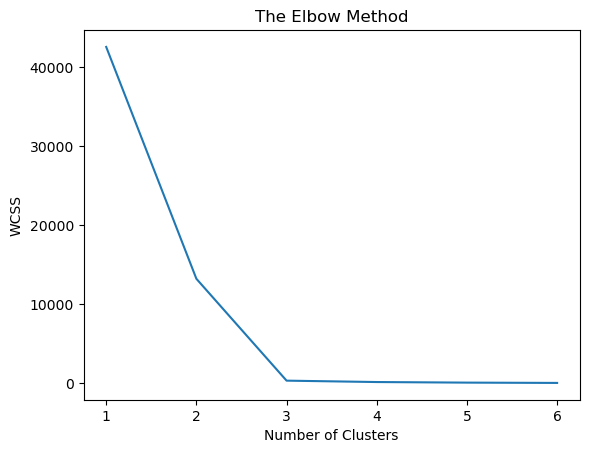

In [26]:
wcss = []

for i in range(1, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)

number_clusters = range(1, 7)

plt.plot(number_clusters, wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')


In [27]:
# specify the number ofclusters (in this case, let's choose 3)
num_clusters= 3
#perform k-means clustering
kmeans =KMeans(n_clusters= num_clusters, random_state=42)
kmeans.fit(X)
            

KMeans(n_clusters=3, random_state=42)

In [28]:
# get the cluster labels for each data point
labels = kmeans.labels_

#add the cluster lables to the dataframe
df['Cluster'] = labels

In [29]:
df.head()

,country,Latitude,Longitude,Language,Cluster
0,USA,44.97,-103.77,English,2
1,Canada,62.40,-96.80,English,2
2,France,46.75,2.40,French,0
3,UK,54.01,-2.53,English,0
4,Germany,51.15,10.40,German,0


In [30]:
# Visualize the clusters
plt.figure(figsize=(8, 6))

# Assign different colors for each cluster
colors = ['red', 'green', 'blue']

for i in range(num_clusters):
    cluster_data = df[df['cluster'] == i]

    plt.scatter(
        cluster_data['Longitude'],
        cluster_data['Latitude'],
        color=colors[i],
        label='Cluster {}'.format(i + 1)
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering of the Countries')
plt.legend()

plt.show()

KeyError: 'cluster'

<Figure size 800x600 with 0 Axes>